In [3]:
import pandas as pd
import scanpy as sc
import seaborn as sns
import numpy as np
import scipy.sparse as sp
import os
import re
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, MaxNLocator, FixedLocator

os.environ["TZ"] = "Europe/Berlin"
import time
time.tzset()

def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)


In [4]:
OUT_DIR = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas"

In [5]:
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"

mp_scores = pd.read_csv(f"{BASE}/results/09_HIHAtlas/09_03_nmf_downsampled/mp_scores_healthy.csv", index_col=0)

In [6]:
adata = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/03_HIHAtlas/HIHAtlas_ds_TICAannot_tmin2.h5ad")

## Annotation comparison between HIHAtlas celltypes and TICAtlas celltypes level 1 (tmin=2)

In [47]:
hiha_col = "cell_type"
tica_col = "decoupler_level1_celltype"

checkpoint(f"HIHA labels: {adata.obs[hiha_col].dropna().unique().tolist()}")
checkpoint(f"TICA labels: {adata.obs[tica_col].dropna().unique().tolist()}")

[2026-09-12 12:36:28] HIHA labels: ['Axl+ dendritic cell, human', 'Be cell', 'CD14-low, CD16-positive monocyte', 'CD14-positive, CD16-negative classical monocyte', 'CD141-positive myeloid dendritic cell', 'CD16-negative, CD56-bright natural killer cell, human', 'CD16-positive, CD56-dim natural killer cell, human', 'CD1c-positive myeloid dendritic cell', 'CD4-positive, alpha-beta memory T cell', 'CD8-positive, alpha-beta memory T cell', 'CD8-positive, alpha-beta regulatory T cell', 'CD8aa(I) thymocyte', 'T cell', 'basophil mast progenitor cell', 'central memory CD4-positive, alpha-beta T cell', 'central memory CD8-positive, alpha-beta T cell', 'common lymphoid progenitor', 'common myeloid progenitor', 'double negative thymocyte', 'effector memory CD4-positive, alpha-beta T cell', 'effector memory CD8-positive, alpha-beta T cell', 'erythrocyte', 'innate lymphoid cell', 'intermediate monocyte', 'mature gamma-delta T cell', 'memory B cell', 'memory CCR4-positive regulatory T cell', 'memory

In [48]:
comparison = adata.obs[[hiha_col, tica_col]].dropna().copy()

checkpoint(
    f"Cells with both annotations: {comparison.shape[0]}/{adata.n_obs}"
)

[2026-09-12 12:36:29] Cells with both annotations: 129435/129435


### 1. Confusion Matrix

#### Which celltype does one cell have (in HIHA and TICA)?

In [49]:
ct = pd.crosstab(
    adata.obs[tica_col],   # rows
    adata.obs[hiha_col],   # columns                  
)
checkpoint(f"Cross-tabulation of TICA and HIHA labels:\n{ct}")

[2026-09-12 12:36:32] Cross-tabulation of TICA and HIHA labels:
cell_type                  common myeloid progenitor  \
decoupler_level1_celltype                              
B cells                                            0   
B cells proliferative                              2   
Plasma B cells                                     2   
T cells naive                                      0   
T cells regulatory                                 1   
T helper cells                                    19   
CD4 effector memory                                2   
T cells proliferative                            184   
CD4 recently activated                             0   
CD4 naive-memory                                   0   
CD4 transitional memory                            2   
CD8 pre-exhausted                                  3   
CD8 cytotoxic                                      0   
CD8 effector memory                                1   
CD8 terminally exhausted                

### 2. normalize for percentual accordance: per rows (TICA annotation)

In [50]:
ct_norm_row = ct.div(ct.sum(axis=1), axis=0)

### 3. Heatmap

In [51]:
adata.obs[tica_col].value_counts().index.sort_values().tolist()

['B cells',
 'B cells proliferative',
 'Plasma B cells',
 'T cells naive',
 'T cells regulatory',
 'T helper cells',
 'CD4 effector memory',
 'T cells proliferative',
 'CD4 recently activated',
 'CD4 naive-memory',
 'CD4 transitional memory',
 'CD8 pre-exhausted',
 'CD8 cytotoxic',
 'CD8 effector memory',
 'CD8 terminally exhausted',
 'NK',
 'TAMs C1QC',
 'TAMs proinflammatory',
 'Macro. and mono. prolif.',
 'Monocytes',
 'cDC',
 'pDC',
 'mDC']

In [52]:
tica_order = [
    "B cells",
    'B cells proliferative',
    'Plasma B cells',
    'CD4 effector memory',
    'CD4 naive-memory',
    'CD4 recently activated',
    'CD4 transitional memory',
    'CD8 cytotoxic',
    'CD8 effector memory',
    'CD8 pre-exhausted',
    'CD8 terminally exhausted',
    'T cells naive',
    'T cells proliferative',
    'T cells regulatory',
    'T helper cells',
    'NK',
    'TAMs C1QC',
    'TAMs proinflammatory',
    'Macro. and mono. prolif.',
    'Monocytes',
    'cDC',
    'mDC',
    'pDC']

In [53]:
# reorder columns 

hiha_order = [
    "transitional stage B cell",
    "naive B cell",
    "memory B cell",
    "Be cell",
    "plasma cell",
    "T cell",  
    "effector memory CD4-positive, alpha-beta T cell",
    "CD4-positive, alpha-beta memory T cell",
    "central memory CD4-positive, alpha-beta T cell",
    "effector memory CD8-positive, alpha-beta T cell",
    "CD8-positive, alpha-beta memory T cell",
    "naive thymus-derived CD4-positive, alpha-beta T cell",
    "naive thymus-derived CD8-positive, alpha-beta T cell",
    "CD8aa(I) thymocyte",
    "double negative thymocyte",
    "common lymphoid progenitor",
    "naive regulatory T cell",
    "memory regulatory T cell",
    "memory CCR4-positive regulatory T cell",
    "CD8-positive, alpha-beta regulatory T cell",
    "mucosal-associated invariant T cell",
    "mature gamma-delta T cell",
    "innate lymphoid cell",
    "CD14-positive, CD16-negative classical monocyte",
    "intermediate monocyte",
    "CD14-low, CD16-positive monocyte",
    "common myeloid progenitor",
    "CD16-negative, CD56-bright natural killer cell, human",
    "CD16-positive, CD56-dim natural killer cell, human",
    "natural killer cell",
    "CD1c-positive myeloid dendritic cell",
    "CD141-positive myeloid dendritic cell",
    "Axl+ dendritic cell, human",
    "plasmacytoid dendritic cell",
    "basophil mast progenitor cell",
    "platelet",
    "erythrocyte",
]

hiha_order_present = [  
    label for label in hiha_order
    if label in ct_norm_row.columns
]

tica_order_present = [
    label for label in tica_order
    if label in ct_norm_row.index
]

ct_plot_row = ct_norm_row.reindex(columns=hiha_order_present, 
                                  index=tica_order_present)

checkpoint(f"Ordered HIHA columns: {ct_plot_row.columns.tolist()}")

[2026-09-12 12:37:05] Ordered HIHA columns: ['transitional stage B cell', 'naive B cell', 'memory B cell', 'Be cell', 'plasma cell', 'T cell', 'effector memory CD4-positive, alpha-beta T cell', 'CD4-positive, alpha-beta memory T cell', 'central memory CD4-positive, alpha-beta T cell', 'effector memory CD8-positive, alpha-beta T cell', 'CD8-positive, alpha-beta memory T cell', 'naive thymus-derived CD4-positive, alpha-beta T cell', 'naive thymus-derived CD8-positive, alpha-beta T cell', 'CD8aa(I) thymocyte', 'double negative thymocyte', 'common lymphoid progenitor', 'naive regulatory T cell', 'memory regulatory T cell', 'memory CCR4-positive regulatory T cell', 'CD8-positive, alpha-beta regulatory T cell', 'mucosal-associated invariant T cell', 'mature gamma-delta T cell', 'innate lymphoid cell', 'CD14-positive, CD16-negative classical monocyte', 'intermediate monocyte', 'CD14-low, CD16-positive monocyte', 'common myeloid progenitor', 'CD16-negative, CD56-bright natural killer cell, hum

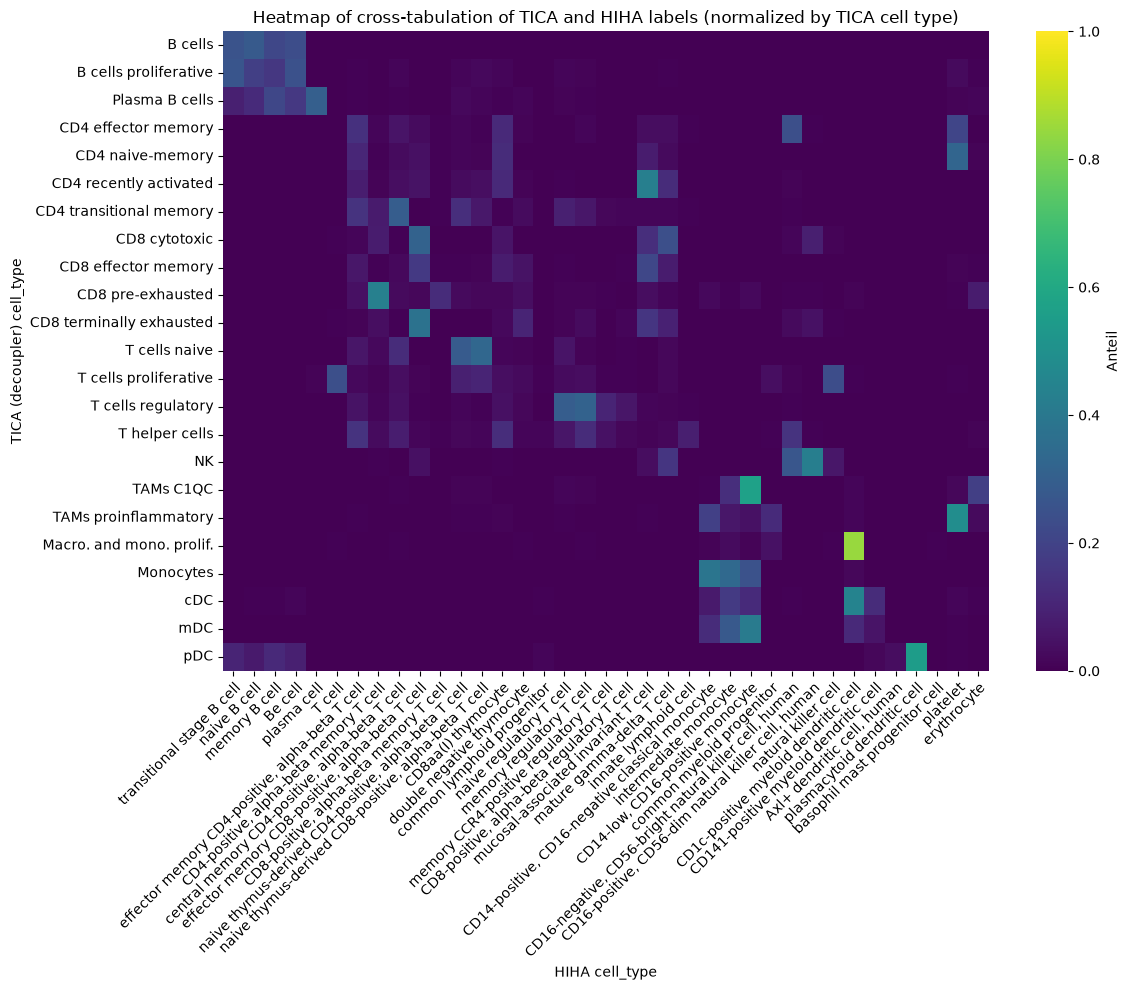

In [48]:
out_pdf = os.path.join(OUT_DIR, "09_10_HIHA_TICA_annotation_heatmap_1.pdf")
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(ct_plot_row, annot=False, fmt=".2f", cmap="viridis", ax=ax, cbar_kws={"label": "Anteil"}, vmin = 0, vmax=1)
ax.set_xlabel("HIHA cell_type")
ax.set_ylabel("TICA (decoupler) cell_type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.set_title("Heatmap of cross-tabulation of TICA and HIHA labels (normalized by TICA cell type)")
plt.tight_layout()
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)

### 4. normalize for percentual accordance: per columns (HIHA annotation)

In [54]:
ct_norm_col = ct.div(ct.sum(axis=0), axis=1)
ct_plot_col = ct_norm_col.reindex(columns=hiha_order_present, 
                                  index=tica_order_present)

checkpoint(f"Ordered HIHA columns: {ct_plot_col.columns.tolist()}")

[2026-09-12 12:38:22] Ordered HIHA columns: ['transitional stage B cell', 'naive B cell', 'memory B cell', 'Be cell', 'plasma cell', 'T cell', 'effector memory CD4-positive, alpha-beta T cell', 'CD4-positive, alpha-beta memory T cell', 'central memory CD4-positive, alpha-beta T cell', 'effector memory CD8-positive, alpha-beta T cell', 'CD8-positive, alpha-beta memory T cell', 'naive thymus-derived CD4-positive, alpha-beta T cell', 'naive thymus-derived CD8-positive, alpha-beta T cell', 'CD8aa(I) thymocyte', 'double negative thymocyte', 'common lymphoid progenitor', 'naive regulatory T cell', 'memory regulatory T cell', 'memory CCR4-positive regulatory T cell', 'CD8-positive, alpha-beta regulatory T cell', 'mucosal-associated invariant T cell', 'mature gamma-delta T cell', 'innate lymphoid cell', 'CD14-positive, CD16-negative classical monocyte', 'intermediate monocyte', 'CD14-low, CD16-positive monocyte', 'common myeloid progenitor', 'CD16-negative, CD56-bright natural killer cell, hum

In [55]:
adata.obs["decoupler_level1_celltype"].value_counts()

decoupler_level1_celltype
B cells                     12006
T cells regulatory          11321
Monocytes                   10528
T cells naive               10311
NK                          10016
pDC                          8738
CD4 naive-memory             6389
CD8 cytotoxic                6346
CD4 transitional memory      6090
CD4 effector memory          5795
T cells proliferative        5160
Plasma B cells               4909
CD8 effector memory          4432
Macro. and mono. prolif.     4067
T helper cells               3718
CD8 pre-exhausted            3433
CD4 recently activated       3112
CD8 terminally exhausted     2651
B cells proliferative        2437
cDC                          2292
mDC                          1921
TAMs proinflammatory         1911
TAMs C1QC                    1852
Name: count, dtype: int64

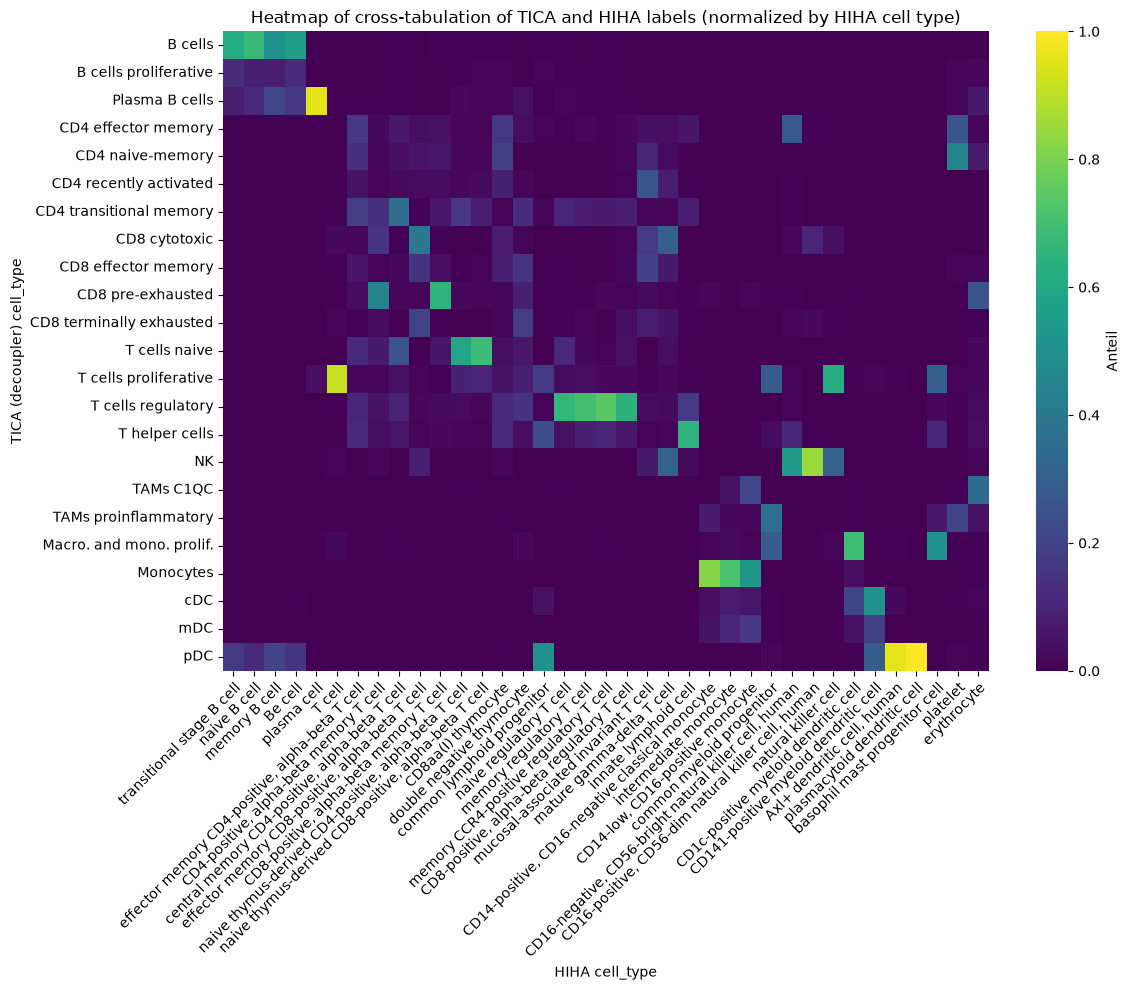

In [47]:
out_pdf = os.path.join(OUT_DIR, "09_10_HIHA_TICA_annotation_heatmap_2.pdf")
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(ct_plot_col, annot=False, fmt=".2f", cmap="viridis", ax=ax, cbar_kws={"label": "Anteil"}, vmin = 0, vmax=1) # ! sort
ax.set_xlabel("HIHA cell_type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.set_ylabel("TICA (decoupler) cell_type")
ax.set_title("Heatmap of cross-tabulation of TICA and HIHA labels (normalized by HIHA cell type)")

plt.tight_layout()
# plt.show()
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)

In [56]:
checkpoint(f"adata.raw available: {adata.raw is not None}")
checkpoint(f"adata.X shape: {adata.shape}")

if adata.raw is not None:
    checkpoint(f"adata.raw shape: {adata.raw.shape}")

[2026-09-12 12:38:30] adata.raw available: True
[2026-09-12 12:38:30] adata.X shape: (129435, 32338)
[2026-09-12 12:38:30] adata.raw shape: (129435, 32357)


In [57]:
sc.tl.rank_genes_groups(adata, groupby=hiha_col, reference="rest", method="wilcoxon", n_genes=adata.n_vars,  key_added="HIHA_markers_wilcoxon", use_raw=False, pts=True)

/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/.environments/kaleidocell_env/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[g

#### HIHA cell type marker genes

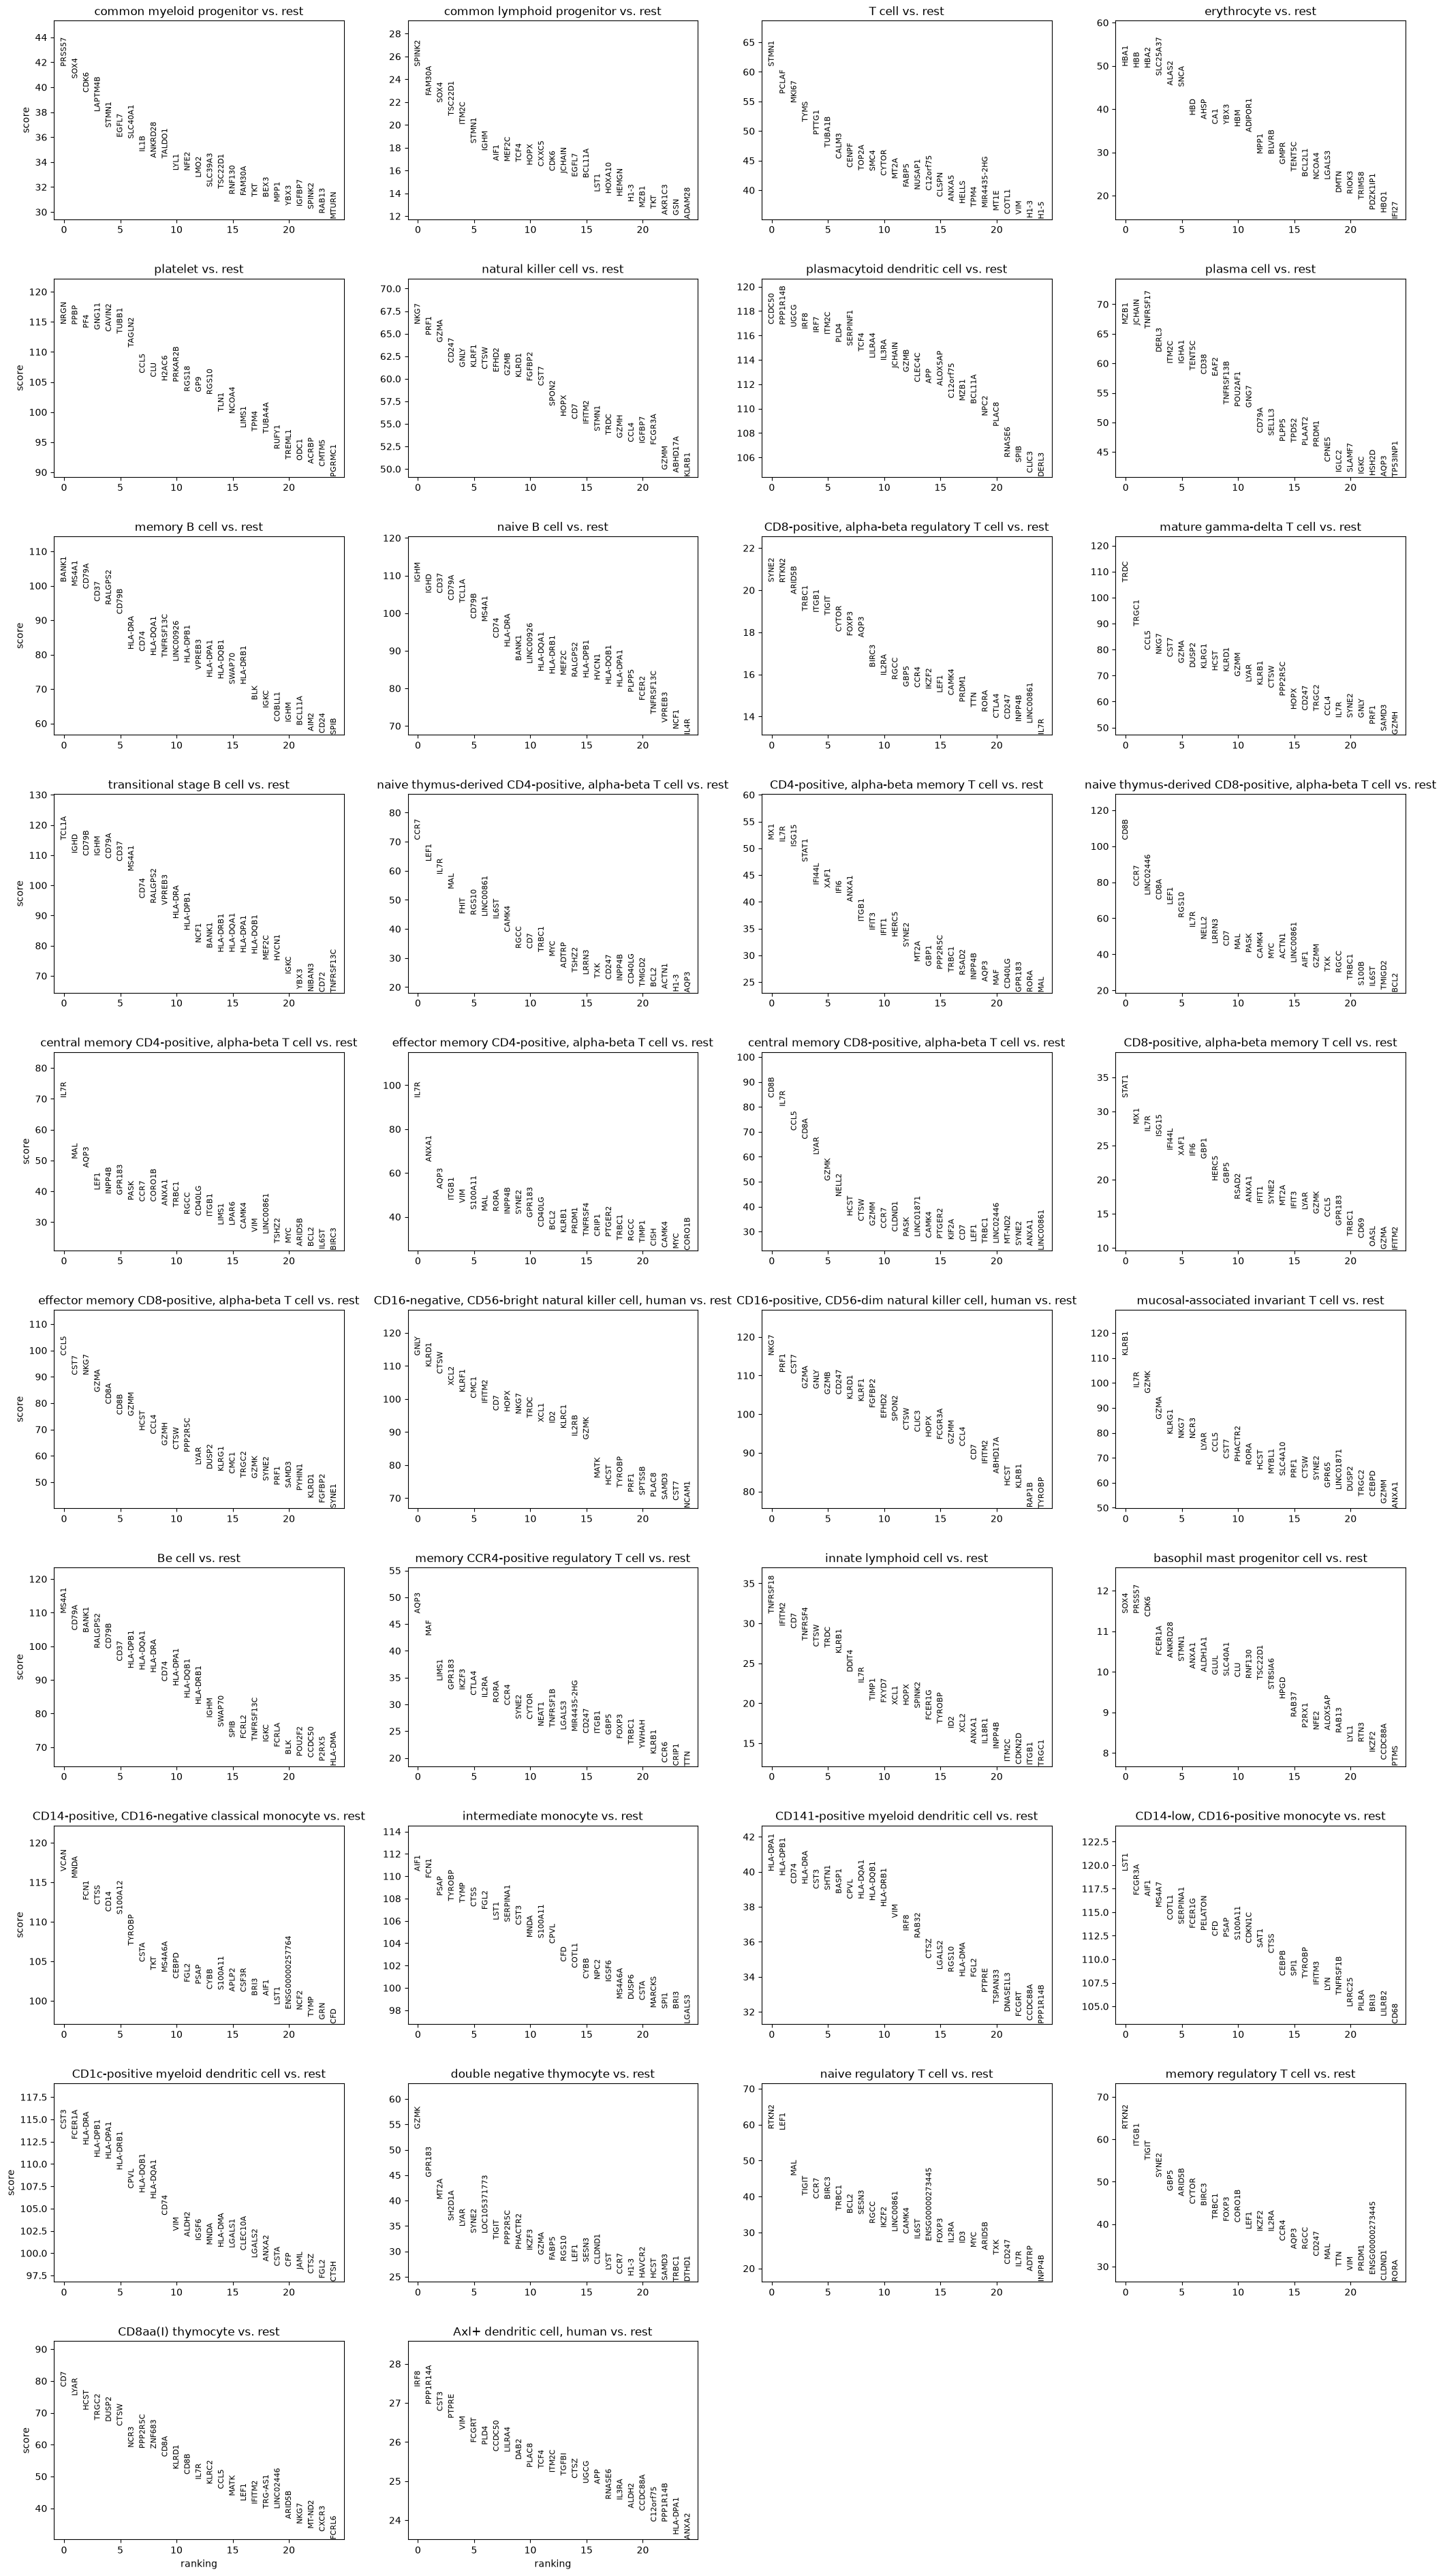

[2026-09-12 13:43:06] Saved HIHA markers plot to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_10_HIHA_markers_wilcoxon.pdf


In [59]:
out_path = os.path.join(OUT_DIR, "09_10_HIHA_markers_wilcoxon.pdf")
sc.pl.rank_genes_groups(adata, key="HIHA_markers_wilcoxon", n_genes=25, sharey=False, show=False)
plt.savefig(out_path, bbox_inches="tight", dpi=300)
plt.show()
plt.close()
checkpoint(f"Saved HIHA markers plot to {out_path}")

In [55]:
group = "T cell"
markers_tcell = sc.get.rank_genes_groups_df(
    adata,
    group=group,
    key="HIHA_markers_wilcoxon",
)
display(markers_tcell.head(15))

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,STMN1,60.892288,9.482586,0.0,0.0,1.0,1.0
1,PCLAF,56.272190,23.115393,0.0,0.0,1.0,1.0
2,MKI67,54.733887,21.476057,0.0,0.0,1.0,1.0
3,TYMS,51.552845,22.150434,0.0,0.0,1.0,1.0
4,PTTG1,49.346626,10.490596,0.0,0.0,1.0,1.0
5,TUBA1B,47.228729,5.706294,0.0,0.0,1.0,1.0
6,CALM3,45.278286,6.055053,0.0,0.0,1.0,1.0
7,CENPF,43.808250,13.109838,0.0,0.0,1.0,1.0
8,TOP2A,43.359722,18.568243,0.0,0.0,1.0,1.0
9,SMC4,43.218475,7.208865,0.0,0.0,1.0,1.0


## Violin plot grid: per MP each celltype with MP-score

In [9]:
celltype_palette = {
    "B cells":                     "#5A5156",
    "B cells proliferative":       "#E4E1E3",
    "Plasma B cells":              "#F6222E",
    "T cells naive":               "#FE00FA",
    "T cells regulatory":          "#16FF32",
    "T helper cells":              "#3283FE",
    "CD4 effector memory":         "#FEAF16",
    "T cells proliferative":       "#B00068",
    "CD4 recently activated":      "#1CFFCE",
    "CD4 naive-memory":            "#90AD1C",
    "CD4 transitional memory":     "#2ED9FF",
    "CD8 pre-exhausted":           "#DEA0FD",
    "CD8 cytotoxic":               "#AA0DFE",
    "CD8 effector memory":         "#F8A19F",
    "CD8 terminally exhausted":    "#325A9B",
    "NK":                          "#C4451C",
    # "Macrophages SPP1":            "#1C8356",
    "TAMs C1QC":                   "#85660D",
    "TAMs proinflammatory":        "#B10DA1",
    "Macro. and mono. prolif.":    "#FBE426",
    "Monocytes":                   "#1CBE4F",
    "cDC":                         "#822E1C",
    "pDC":                         "#333333",
    "mDC":                         "#F7E1A0",
    # "Mast cells":                  "#C075A6",
}

current_cats = set(adata.obs["decoupler_level1_celltype"].cat.categories)
assert set(celltype_palette.keys()) == current_cats, (
    f"Mismatch — missing: {current_cats - set(celltype_palette.keys())}, "
    f"extra: {set(celltype_palette.keys()) - current_cats}"
)
adata.obs["decoupler_level1_celltype"] = adata.obs["decoupler_level1_celltype"].cat.reorder_categories(list(celltype_palette.keys()))



In [10]:
for col in mp_scores.columns:
    if col not in adata.obs.columns:
        adata.obs[col] = mp_scores[col].reindex(adata.obs_names).values

adata.obs["decoupler_level1_celltype"] = adata.obs["decoupler_level1_celltype"].cat.reorder_categories(list(celltype_palette.keys()))

In [12]:
adata.obs.columns

Index(['cohort.cohortGuid', 'sample.sampleKitGuid', 'specimen.specimenGuid',
       'pipeline.fileGuid', 'subject.birthYear', 'subject.ageAtFirstDraw',
       'subject.ageGroup', 'subject.race', 'subject.ethnicity', 'subject.cmv',
       'subject.bmi', 'sample.visitName', 'sample.drawYear',
       'sample.subjectAgeAtDraw', 'batch_id', 'pool_id', 'chip_id', 'well_id',
       'original_barcodes', 'cell_name', 'n_reads', 'n_umis', 'n_genes',
       'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'AIFI_L1',
       'AIFI_L2', 'AIFI_L3', 'disease_ontology_term_id',
       'tissue_ontology_term_id', 'tissue_type', 'suspension_type',
       'assay_ontology_term_id', 'sex_ontology_term_id', 'donor_id',
       'self_reported_ethnicity_ontology_term_id',
       'development_stage_ontology_term_id', 'cell_type_ontology_term_id',
       'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue',
       'self_reported_ethnicity', 'development_stage', 'observation_joinid',
       '

[2026-09-10 13:54:52] Plotting 8 selected MP score columns


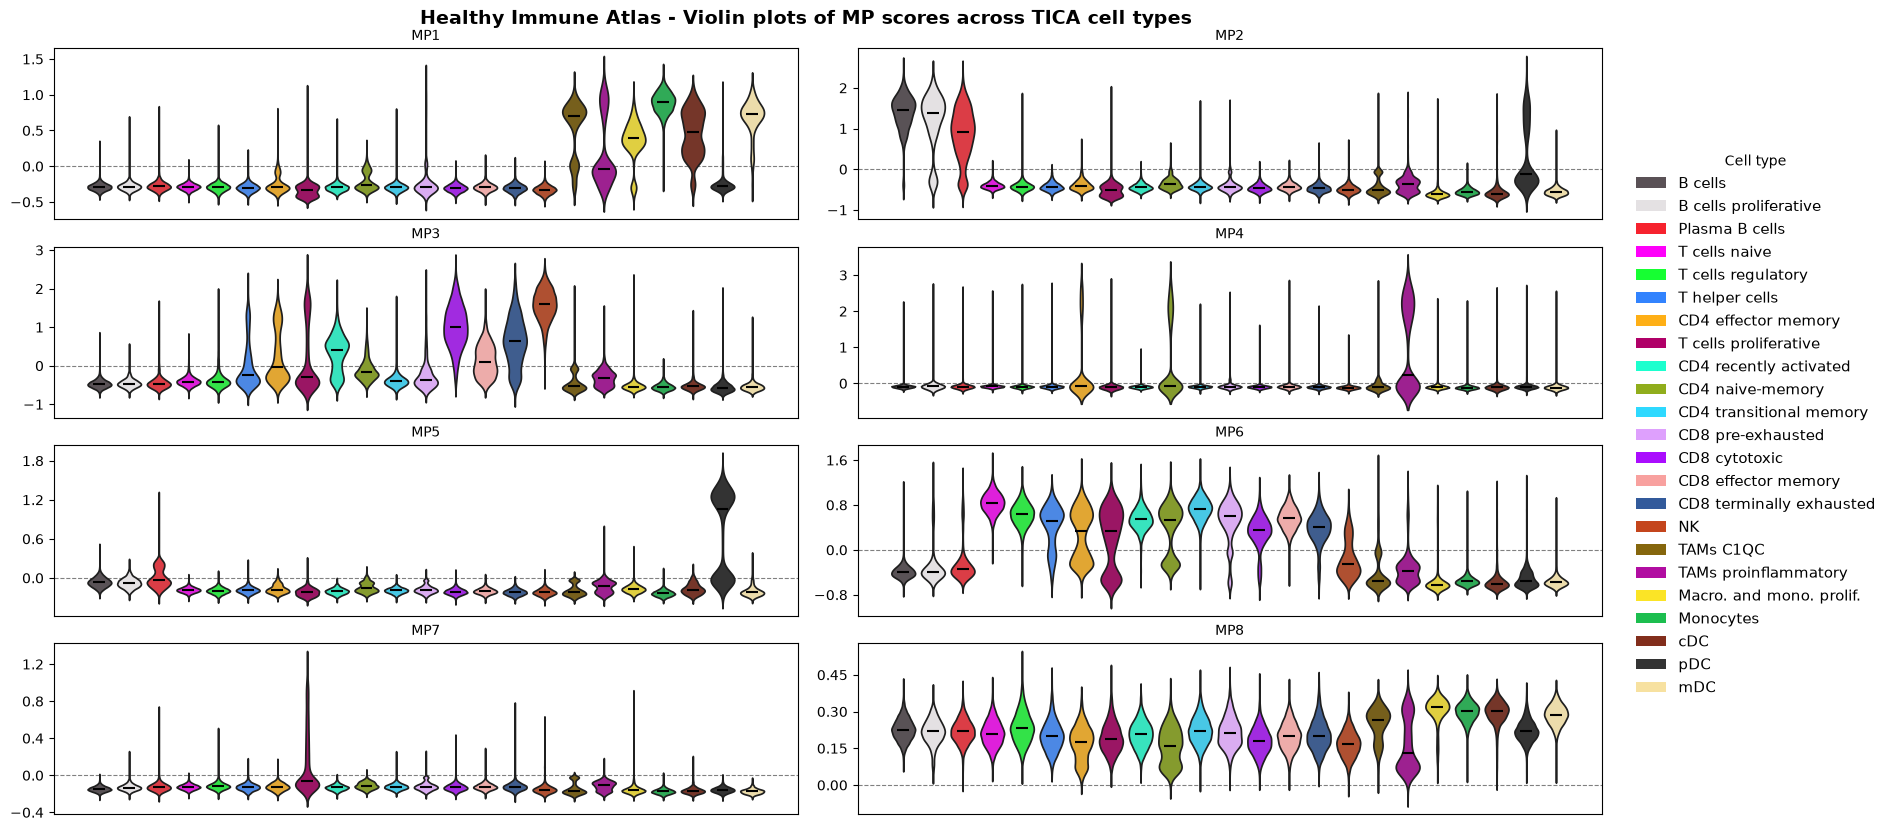

[2026-09-10 13:55:02] Combined PDF with all MP violin plots saved


In [ ]:


mp_score_cols = [col for col in mp_scores.columns if col in adata.obs.columns]
missing_mps = [col for col in mp_scores.columns if col not in mp_scores.columns]
if missing_mps:
    checkpoint(f"WARNING: {len(missing_mps)} selected MPs not found in mp_scores.columns: {missing_mps}")

checkpoint(f"Plotting {len(mp_score_cols)} selected MP score columns")

n_mps = len(mp_score_cols)
n_cols = 2
n_rows = -(-n_mps // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 2), constrained_layout=True)
axes = axes.flatten()

for i, mp_col in enumerate(mp_score_cols):
    mp_name = mp_col.replace("_score", "")
    sns.violinplot(
        data=adata.obs,
        x="decoupler_level1_celltype",
        y=mp_col,
        hue="decoupler_level1_celltype",
        palette=celltype_palette,
        order=list(celltype_palette.keys()),
        legend=False,
        ax=axes[i],
        inner=None,
    )
    medians = adata.obs.groupby("decoupler_level1_celltype", observed=True)[mp_col].median()
    medians = medians.reindex(celltype_palette.keys())
    for x_pos, med_val in enumerate(medians):
        axes[i].hlines(med_val, x_pos - 0.2, x_pos + 0.2, colors="black", linewidth=1.5, zorder=3)

    
    axes[i].set_title(mp_name, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].set_xticks([])
    axes[i].axhline(0, color="grey", linestyle="--", linewidth=0.8, zorder=0)
    axes[i].yaxis.set_major_locator(MaxNLocator(nbins=5))


for j in range(n_mps, len(axes)):
    axes[j].axis("off")



legend_handles = [Patch(facecolor=color, label=ct) for ct, color in celltype_palette.items()]
fig.legend(handles=legend_handles, loc="center left", bbox_to_anchor=(1.01, 0.5),fontsize=11, title="Cell type", frameon=False)
fig.suptitle("Healthy Immune Atlas - Violin plots of MP scores across TICA cell types", fontsize=14, y=1.02, fontweight="bold")
plt.savefig(os.path.join(OUT_DIR, "09_10_violin_all_MPs_per_celltype.pdf"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
checkpoint("Combined PDF with all MP violin plots saved")



## Analyze MP4 of HIHA

In [27]:
mp_cols = sorted(
    [
        col for col in adata.obs.columns
        if re.match(r"^MP\d+_score$", str(col))
    ],
    key=lambda x: int(re.search(r"\d+", x).group())
)

checkpoint(f"MP-score columns ({len(mp_cols)}): {mp_cols}")

target_mp = "MP4_score"
threshold = 0.5
celltype_col = "decoupler_level1_celltype"  

# Nur Zellen, bei denen alle MP-Scores vorliegen
valid_scores = adata.obs[mp_cols].notna().all(axis=1)

# Höchster Score über alle MP-Spalten pro Zelle
top_mp = adata.obs.loc[valid_scores, mp_cols].idxmax(axis=1)

# Selektionsmaske:
# MP4 ist der höchste Score UND MP4 > 0.5
mp4_highest = (
    valid_scores
    & (top_mp.reindex(adata.obs_names) == target_mp)
    & (adata.obs[target_mp] > threshold)
)

adata_mp4 = adata[mp4_highest].copy()

checkpoint(
    f"Selected {adata_mp4.n_obs}/{adata.n_obs} cells: "
    f"{target_mp} highest and score > {threshold}"
)

[2026-09-12 12:01:18] MP-score columns (8): ['MP1_score', 'MP2_score', 'MP3_score', 'MP4_score', 'MP5_score', 'MP6_score', 'MP7_score', 'MP8_score']
[2026-09-12 12:01:18] Selected 4735/129435 cells: MP4_score highest and score > 0.5


In [28]:

# calculate amount of present celltypes

celltype_counts = (
    adata_mp4.obs[celltype_col]
    .dropna()
    .value_counts()
)

celltype_percent = (
    adata_mp4.obs[celltype_col]
    .dropna()
    .value_counts(normalize=True)
    .mul(100)
)

celltype_summary = pd.DataFrame({
    "n_cells": celltype_counts,
    "percent": celltype_percent,
})

display(celltype_summary)

,n_cells,percent
decoupler_level1_celltype,,
CD4 naive-memory,2111,44.582893
CD4 effector memory,1202,25.385428
TAMs proinflammatory,952,20.105597
B cells proliferative,70,1.478353
TAMs C1QC,53,1.119324
pDC,52,1.098205
Plasma B cells,52,1.098205
T cells proliferative,41,0.865892
CD8 effector memory,40,0.844773


[2026-09-12 12:16:36] Plot columns: ['celltype', 'n_cells', 'percent']


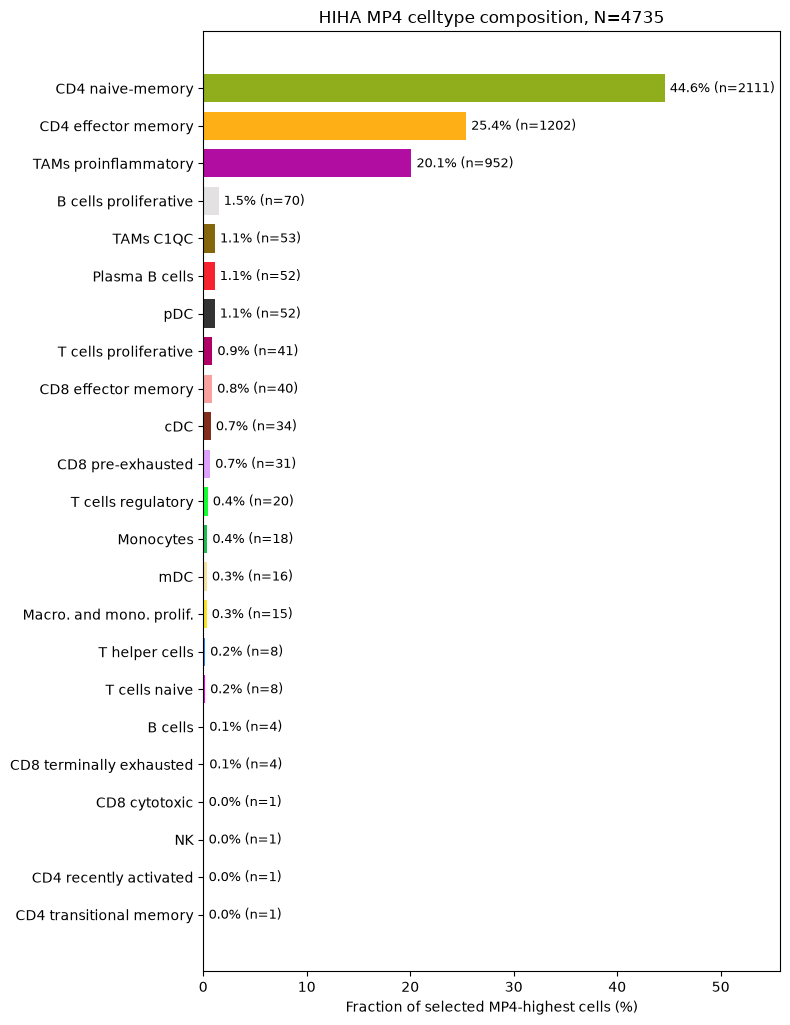

[2026-09-12 12:16:37] Saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_10_MP4_celltype_composition.pdf


In [39]:
plot_df = (
    pd.DataFrame({
        "celltype": celltype_counts.index,
        "n_cells": celltype_counts.values,
        "percent": celltype_percent.reindex(celltype_counts.index).values,
    })
    .sort_values("percent", ascending=True)
)

checkpoint(f"Plot columns: {plot_df.columns.tolist()}")
# display(plot_df)

missing_palette = set(plot_df["celltype"]) - set(celltype_palette)
if missing_palette:
    raise ValueError(
        f"Missing colors in celltype_palette: {sorted(missing_palette)}"
    )

bar_colors = [
    celltype_palette[celltype]
    for celltype in plot_df["celltype"]
]

fig, ax = plt.subplots(figsize=(8, max(4, 0.45 * len(plot_df))))

bars = ax.barh(
    y=plot_df["celltype"],
    width=plot_df["percent"],
    color=bar_colors,
    edgecolor="none",
    height=0.75,
)

# Prozentwerte und n an Balken schreiben
for bar, percent, n_cells in zip(
    bars,
    plot_df["percent"],
    plot_df["n_cells"],
):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{percent:.1f}% (n={n_cells})",
        va="center",
        ha="left",
        fontsize=9,
    )

ax.set_xlabel("Fraction of selected MP4-highest cells (%)")
ax.set_ylabel("")
ax.set_title(f"HIHA MP4 celltype composition, N={adata_mp4.n_obs}")
ax.set_xlim(0, plot_df["percent"].max() * 1.25)

plt.tight_layout()

out_pdf = os.path.join(
    OUT_DIR,
    f"09_10_MP4_celltype_composition.pdf",
)
fig.savefig(out_pdf, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)

checkpoint(f"Saved: {out_pdf}")

In [42]:
other_threshold = 1.0  # Prozent
plot_df = (
    pd.DataFrame({
        "celltype": celltype_counts.index,
        "n_cells": celltype_counts.values,
        "percent": celltype_percent.reindex(celltype_counts.index).values,
    })
    .sort_values("percent", ascending=True)
)
plot_df["celltype"] = plot_df["celltype"].astype(str)

# Kleine Kategorien zu "Other" umbenennen
plot_df["celltype_plot"] = plot_df["celltype"].where(
    plot_df["percent"] >= other_threshold,
    "Other",
)

# n_cells aggregieren; alle <1%-Gruppen werden zu einer Other-Zeile
plot_df_final = (
    plot_df
    .groupby("celltype_plot", as_index=False, observed=True)["n_cells"]
    .sum()
)

# Prozentwerte nach Aggregation neu berechnen
plot_df_final["percent"] = (
    plot_df_final["n_cells"]
    / plot_df_final["n_cells"].sum()
    * 100
)

# Sortieren: Other unten, übrige nach Häufigkeit
plot_df_final["is_other"] = plot_df_final["celltype_plot"].eq("Other")

plot_df_final = (
    plot_df_final
    .sort_values(
        ["is_other", "percent"],
        ascending=[True, False],
    )
    .drop(columns="is_other")
)

checkpoint(f"Celltype composition after <{other_threshold}% aggregation:")
display(plot_df_final)

[2026-09-12 12:19:32] Celltype composition after <1.0% aggregation:


,celltype_plot,n_cells,percent
2,CD4 naive-memory,2111,44.582893
1,CD4 effector memory,1202,25.385428
6,TAMs proinflammatory,952,20.105597
0,B cells proliferative,70,1.478353
5,TAMs C1QC,53,1.119324
4,Plasma B cells,52,1.098205
7,pDC,52,1.098205
3,Other,243,5.131996


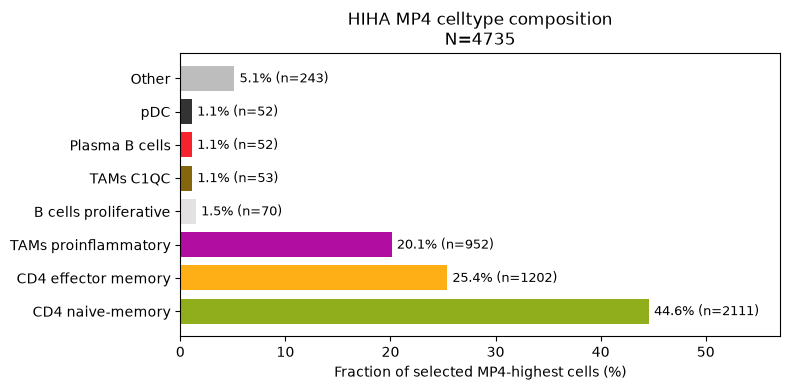

In [ ]:


bar_colors = [
    "#BDBDBD" if ct == "Other" else celltype_palette[ct]
    for ct in plot_df_final["celltype_plot"]
]

fig, ax = plt.subplots(
    figsize=(8, max(4, 0.45 * len(plot_df_final)))
)

bars = ax.barh(
    y=plot_df_final["celltype_plot"],
    width=plot_df_final["percent"],
    color=bar_colors,
    edgecolor="none",
    height=0.75,
)

for bar, percent, n_cells in zip(
    bars,
    plot_df_final["percent"],
    plot_df_final["n_cells"],
):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{percent:.1f}% (n={n_cells})",
        va="center",
        ha="left",
        fontsize=9,
    )

ax.set_xlabel("Fraction of selected MP4-highest cells (%)")
ax.set_ylabel("")
ax.set_title(
    f"HIHA MP4 celltype composition\n"
    f"N={adata_mp4.n_obs}"
)

ax.set_xlim(0, plot_df_final["percent"].max() * 1.28)

plt.tight_layout()
out_pdf = os.path.join(
    OUT_DIR,
    f"09_10_MP4_celltype_composition_smaLL.pdf",
)
fig.savefig(out_pdf, bbox_inches="tight", dpi=300)
plt.show()
plt.close()